# Тест примеры для поиска лучших узлов полным перебором

In [47]:
import numpy as np

import osmnx as ox
import networkx as nx
import pandas as pd
import geopandas as gpd

from genesis.best_points import BestNodesFull, BestNodeHillClimbing
from genesis.metrics import ArrivalTime, CoverIndex
from genesis.states import FirstArrivalUnitState
from genesis.utils import *
from genesis.tools import k_v_dict

ImportError: cannot import name 'k_v_dict' from 'genesis.tools' (g:\GitRepositories\_Dislocation\genesis\work\genesis\genesis\tools.py)

In [2]:
def load_G():
    return ox.load_graphml("tests/data/test_rng.ml")

def load_area():
    return gpd.read_file("tests/data/test_polygon.gpkg")

def create_G():
    '''
        max: 21
        mean: 8.67
        median: 8.0
        ip-10: 66.67
        ip-20: 93.33
    '''
    G = nx.MultiDiGraph()
    G.add_edge(1, 2, key=0, travel_time=3)
    G.add_edge(1, 3, key=0, travel_time=2)
    G.add_edge(1, 4, key=0, travel_time=5)
    G.add_edge(2, 3, key=0, travel_time=2)
    G.add_edge(2, 5, key=0, travel_time=5)
    G.add_edge(2, 6, key=0, travel_time=7)
    G.add_edge(3, 2, key=0, travel_time=3)
    G.add_edge(3, 7, key=0, travel_time=3)
    G.add_edge(3, 8, key=0, travel_time=4)
    G.add_edge(3, 9, key=0, travel_time=5)
    G.add_edge(4, 3, key=0, travel_time=2)
    G.add_edge(4, 8, key=0, travel_time=4)
    G.add_edge(4, 10, key=0, travel_time=12)
    G.add_edge(4, 11, key=0, travel_time=10)
    G.add_edge(5, 8, key=0, travel_time=8)
    G.add_edge(5, 10, key=0, travel_time=8)
    G.add_edge(5, 12, key=0, travel_time=6)
    G.add_edge(5, 13, key=0, travel_time=9)
    G.add_edge(5, 12, key=0, travel_time=8)
    G.add_edge(6, 8, key=0, travel_time=1)
    G.add_edge(6, 9, key=0, travel_time=4)
    G.add_edge(6, 12, key=0, travel_time=4)
    G.add_edge(7, 10, key=0, travel_time=4)
    G.add_edge(7, 11, key=0, travel_time=9)
    G.add_edge(7, 13, key=0, travel_time=7)
    G.add_edge(8, 10, key=0, travel_time=6)
    G.add_edge(8, 13, key=0, travel_time=8)
    G.add_edge(9, 14, key=0, travel_time=10)
    G.add_edge(10, 13, key=0, travel_time=7)
    G.add_edge(10, 14, key=0, travel_time=5)
    G.add_edge(11, 12, key=0, travel_time=7)
    G.add_edge(11, 15, key=0, travel_time=7)
    G.add_edge(12, 13, key=0, travel_time=8)
    return G

# Примеры

## Простой расчет

In [9]:
G = create_G()

best_nodes, best_metric = BestNodesFull(FirstArrivalUnitState(), ArrivalTime())(G)
print(best_nodes, best_metric)
best_nodes, best_metric = BestNodesFull(FirstArrivalUnitState(), ArrivalTime(np.max))(G)
print(best_nodes, best_metric)
best_nodes, best_metric = BestNodesFull(FirstArrivalUnitState(), CoverIndex())(G)
print(best_nodes, best_metric)
best_nodes, best_metric = BestNodesFull(FirstArrivalUnitState(), CoverIndex(20))(G)
print(best_nodes, best_metric)

[1] 9.666666666666666
[4] 18.0
[1] 60.0
[4] 100.0


### Для большого графа

In [33]:
G = load_G()
area = load_area()

### Эталонное размещение

Для всех узлов графа, при допустимом охвате графа не менее 95%.

In [55]:
test_nodes = list(G.nodes())
metric_at_mean = {}
metric_at_max = {}
metric_ci_10 = {}
metric_ci_20 = {}

g_number_of_nodes = len(test_nodes)
appr_val=0.95
appr_nodes=g_number_of_nodes*appr_val

for i, test_node in enumerate(test_nodes):
    print(round(i/g_number_of_nodes,3), end='\r')
    times, _ = FirstArrivalUnitState()(G, points=[test_node])
    if len(times)>=appr_nodes:
        metric_at_mean[test_node] = ArrivalTime()(times)
        metric_at_max[test_node] = ArrivalTime(np.max)(times)
        metric_ci_10[test_node] = CoverIndex()(times)
        metric_ci_20[test_node] = CoverIndex(20)(times)
print('ready')

nx.set_node_attributes(G, metric_at_mean, 'metric_at_mean')
nx.set_node_attributes(G, metric_at_max, 'metric_at_max')
nx.set_node_attributes(G, metric_ci_10, 'metric_ci_10')
nx.set_node_attributes(G, metric_ci_20, 'metric_ci_20')

print('metric_at_mean', k_v_dict(metric_at_mean), min(metric_at_mean.values()), sep='\t')
print('metric_at_max', k_v_dict(metric_at_max), min(metric_at_max.values()), sep='\t')
print('metric_ci_10', k_v_dict(metric_ci_10, max), max(metric_ci_10.values()), sep='\t')
print('metric_ci_20', k_v_dict(metric_ci_20, max), max(metric_ci_20.values()), sep='\t')

ready
metric_at_mean	426923808	8.355415617070701
metric_at_max	4116049991	18.03619171428572
metric_ci_10	3981463776	67.53270348837209
metric_ci_20	426923809	100.0


Для всех узлов графа, при допустимом охвате области `area` не менее 95%. Метрика рассчитывается только для узлов `area`.

In [56]:
test_nodes = list(G.nodes())
metric_at_mean = {}
metric_at_max = {}
metric_ci_10 = {}
metric_ci_20 = {}

g_nodes = ox.graph_to_gdfs(G, edges=False)
points_mask = g_nodes.within(area.iloc[0].geometry)

g_number_of_nodes = len(test_nodes)
appr_val=0.95
appr_nodes=points_mask.sum()*appr_val

for i, test_node in enumerate(test_nodes):
    print(round(i/g_number_of_nodes,3), end='\r')
    times, _ = FirstArrivalUnitState()(G, points=[test_node], area=points_mask)

    if len(times)>=appr_nodes:
        metric_at_mean[test_node] = ArrivalTime()(times)
        metric_at_max[test_node] = ArrivalTime(np.max)(times)
        metric_ci_10[test_node] = CoverIndex()(times)
        metric_ci_20[test_node] = CoverIndex(20)(times)
print('ready')

nx.set_node_attributes(G, metric_at_mean, 'metric_at_mean_area')
nx.set_node_attributes(G, metric_at_max, 'metric_at_max_area')
nx.set_node_attributes(G, metric_ci_10, 'metric_ci_10_area')
nx.set_node_attributes(G, metric_ci_20, 'metric_ci_20_area')

print('metric_at_mean', k_v_dict(metric_at_mean), min(metric_at_mean.values()), sep='\t')
print('metric_at_max', k_v_dict(metric_at_max), min(metric_at_max.values()), sep='\t')
print('metric_ci_10', k_v_dict(metric_ci_10, max), max(metric_ci_10.values()), sep='\t')
print('metric_ci_20', k_v_dict(metric_ci_20, max), max(metric_ci_20.values()), sep='\t')

ready
metric_at_mean	1577701962	4.328401644772975
metric_at_max	4116030638	11.343054285714286
metric_ci_10	2034401285	98.83772910147519
metric_ci_20	290700344	100.0


In [57]:
ox.save_graphml(G, "../tests/data/test_rng2.ml")
ox.save_graph_geopackage(G, "../tests/data/test_rng2.gpkg")

#### Все узлы графа

In [26]:
pb = Progressbar(G.number_of_nodes(), bins=40)
bnf = timing(BestNodesFull(FirstArrivalUnitState(), ArrivalTime()))

# nodes_list = list(G.nodes())[:100]
best_nodes, best_metric = bnf(env=G, node_calc_end_function=pb)  #, nodes_list=nodes_list)
print(best_nodes, best_metric)

|########################################| 100.0%
ВРЕМЯ: 350.83 сек
[426923808] 8.355415617070701


<Axes: >

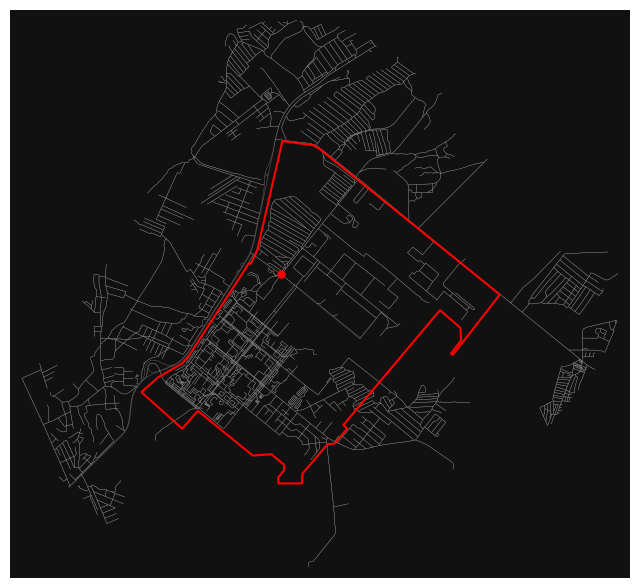

In [34]:
# Печать карты
nodes = ox.graph_to_gdfs(G, edges=False)

fig, ax = ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False)
area.boundary.plot(ax=ax, color='r')
nodes.loc[best_nodes].plot(ax=ax, markersize=25, color='red')

AttributeError: PathCollection.set() got an unexpected keyword argument 'marker_size'

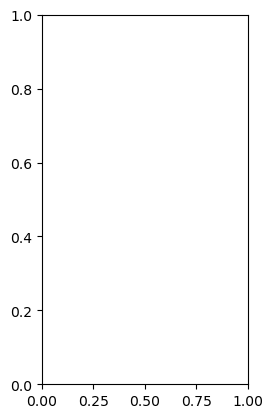

In [32]:
# Печать карты
nodes = ox.graph_to_gdfs(G, edges=False)
# ax = nodes[nodes['nearest'].notna()].plot(markersize=1, column='route_times')
fig, ax = ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False)
area.boundary.plot(ax=ax, color='r')
nodes.loc[best_nodes].plot(ax=ax, markersize=25, color='red')

#### Часть узлов, разные метрики